# Conversation Logs: Preliminary Analysis

Comparing the RAG condition vs. the Standard (control) condition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rag = pd.read_csv('conversation_logs/conversation_logs_rag.csv')
standard = pd.read_csv('conversation_logs/conversation_logs_standard.csv')

print(f'RAG file: {rag.shape[0]} rows, {rag["user_id"].nunique()} unique users')
print(f'Standard file: {standard.shape[0]} rows, {standard["account_id"].nunique()} unique users')

RAG file: 25000 rows, 948 unique users
Standard file: 51729 rows, 10888 unique users


## 1. General Analysis: Age & Location Distributions

In [2]:
# Get per-user demographics (one row per user)
rag_users = rag.drop_duplicates(subset='user_id')[['user_id', 'user_age', 'location_state']]
std_users = standard.drop_duplicates(subset='account_id')[['account_id', 'user_age', 'location_state']]

print(f'RAG: {len(rag_users)} unique users')
print(f'Standard: {len(std_users)} unique users')

RAG: 948 unique users
Standard: 10888 unique users


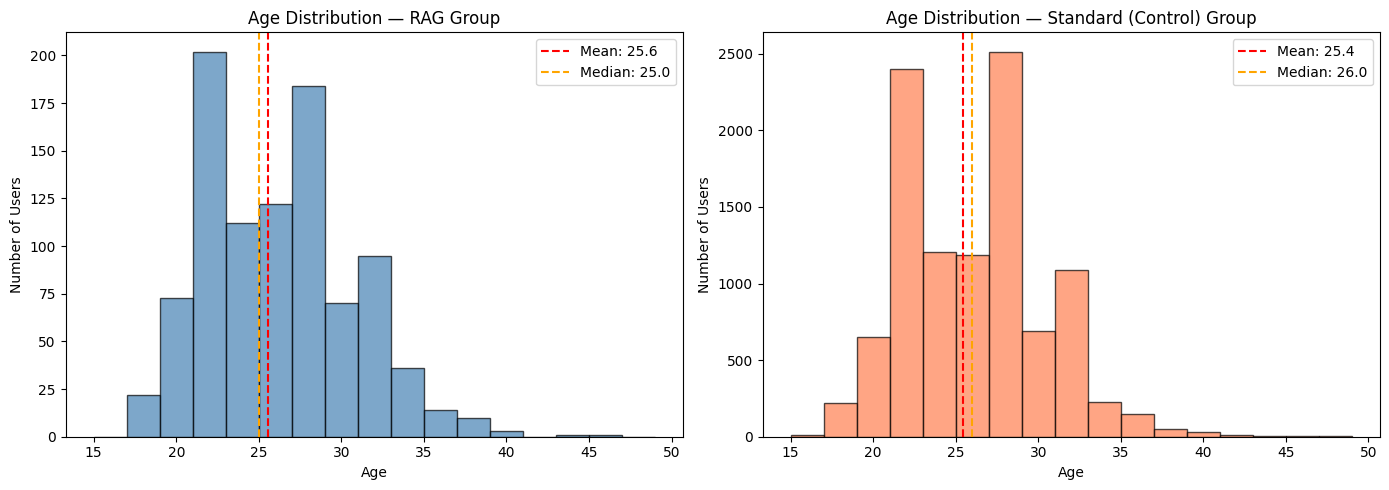


--- RAG Age Summary ---
count    945.000000
mean      25.572487
std        4.501328
min       18.000000
25%       21.000000
50%       25.000000
75%       28.000000
max       45.000000
Name: user_age, dtype: float64

--- Standard Age Summary ---
count    10447.000000
mean        25.449316
std          4.248964
min         15.000000
25%         21.000000
50%         26.000000
75%         28.000000
max         48.000000
Name: user_age, dtype: float64


In [3]:
# --- Age distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

rag_ages = rag_users['user_age'].dropna()
std_ages = std_users['user_age'].dropna()

bins = np.arange(15, 50, 2)

axes[0].hist(rag_ages, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Age Distribution — RAG Group')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(rag_ages.mean(), color='red', linestyle='--', label=f'Mean: {rag_ages.mean():.1f}')
axes[0].axvline(rag_ages.median(), color='orange', linestyle='--', label=f'Median: {rag_ages.median():.1f}')
axes[0].legend()

axes[1].hist(std_ages, bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Age Distribution — Standard (Control) Group')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(std_ages.mean(), color='red', linestyle='--', label=f'Mean: {std_ages.mean():.1f}')
axes[1].axvline(std_ages.median(), color='orange', linestyle='--', label=f'Median: {std_ages.median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n--- RAG Age Summary ---')
print(rag_ages.describe())
print('\n--- Standard Age Summary ---')
print(std_ages.describe())

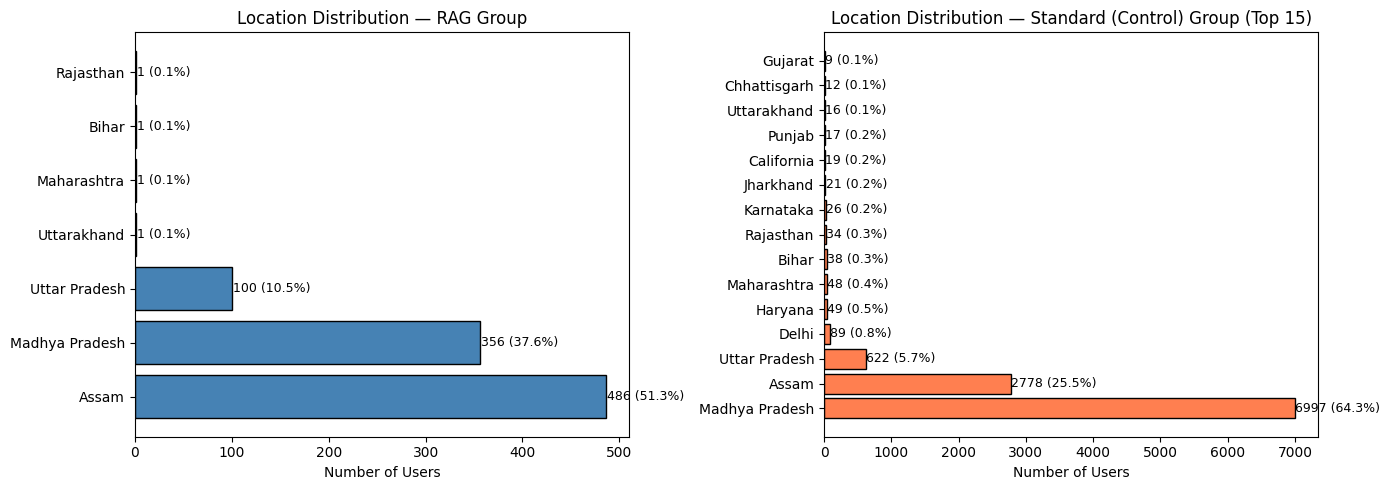


--- RAG Location Counts ---
location_state
Assam             486
Madhya Pradesh    356
Uttar Pradesh     100
Uttarakhand         1
Maharashtra         1
Bihar               1
Rajasthan           1
Name: count, dtype: int64
Missing: 2

--- Standard Location Counts (all) ---
location_state
Madhya Pradesh       6997
Assam                2778
Uttar Pradesh         622
Delhi                  89
Haryana                49
Maharashtra            48
Bihar                  38
Rajasthan              34
Karnataka              26
Jharkhand              21
California             19
Punjab                 17
Uttarakhand            16
Chhattisgarh           12
Gujarat                 9
Himachal Pradesh        9
Illinois                6
West Bengal             6
Tripura                 5
Meghalaya               5
Odisha                  5
Nagaland                4
Tamil Nadu              3
Andhra Pradesh          2
Goa                     2
Chandigarh              2
Kerala                  2
Arunacha

In [4]:
# --- Location distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rag_loc = rag_users['location_state'].value_counts()
std_loc = std_users['location_state'].value_counts()

axes[0].barh(rag_loc.index, rag_loc.values, color='steelblue', edgecolor='black')
axes[0].set_title('Location Distribution — RAG Group')
axes[0].set_xlabel('Number of Users')
for i, v in enumerate(rag_loc.values):
    axes[0].text(v + 1, i, f'{v} ({v/len(rag_users)*100:.1f}%)', va='center', fontsize=9)

axes[1].barh(std_loc.index[:15], std_loc.values[:15], color='coral', edgecolor='black')
axes[1].set_title('Location Distribution — Standard (Control) Group (Top 15)')
axes[1].set_xlabel('Number of Users')
for i, v in enumerate(std_loc.values[:15]):
    axes[1].text(v + 1, i, f'{v} ({v/len(std_users)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n--- RAG Location Counts ---')
print(rag_loc)
print(f'Missing: {rag_users["location_state"].isna().sum()}')
print('\n--- Standard Location Counts (all) ---')
print(std_loc)
print(f'Missing: {std_users["location_state"].isna().sum()}')

## 2. Average Number of Messages Per User

**Filtering:**
- RAG: Exclude `flow_type == STATIC_FLOW`, then exclude user messages with < 3 words
- Standard: Exclude user messages with < 3 words

We only count USER messages (not BOT) for the RAG file.

In [5]:
# --- RAG: filter out STATIC_FLOW, keep USER messages, filter < 3 words ---
rag_filtered = rag[
    (rag['flow_type'] != 'STATIC_FLOW') &
    (rag['sender'] == 'USER')
].copy()
rag_filtered['word_count'] = rag_filtered['message'].astype(str).str.split().str.len()
rag_filtered = rag_filtered[rag_filtered['word_count'] >= 3]

rag_msgs_per_user = rag_filtered.groupby('user_id').size()

print(f'RAG (after filtering): {len(rag_filtered)} messages from {rag_msgs_per_user.shape[0]} users')
print(f'Average messages per user: {rag_msgs_per_user.mean():.2f}')
print(f'Median messages per user: {rag_msgs_per_user.median():.2f}')
print()
print(rag_msgs_per_user.describe())

RAG (after filtering): 583 messages from 153 users
Average messages per user: 3.81
Median messages per user: 2.00

count    153.000000
mean       3.810458
std        3.628744
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       17.000000
dtype: float64


In [6]:
# --- Standard: filter < 3 words ---
std_filtered = standard.copy()
std_filtered['word_count'] = std_filtered['user_message'].astype(str).str.split().str.len()
std_filtered = std_filtered[std_filtered['word_count'] >= 3]

std_msgs_per_user = std_filtered.groupby('account_id').size()

print(f'Standard (after filtering): {len(std_filtered)} messages from {std_msgs_per_user.shape[0]} users')
print(f'Average messages per user: {std_msgs_per_user.mean():.2f}')
print(f'Median messages per user: {std_msgs_per_user.median():.2f}')
print()
print(std_msgs_per_user.describe())

Standard (after filtering): 23715 messages from 6698 users
Average messages per user: 3.54
Median messages per user: 2.00

count    6698.000000
mean        3.540609
std         4.420307
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        73.000000
dtype: float64


## 3. Histogram: Messages Per User (RAG vs. Standard)

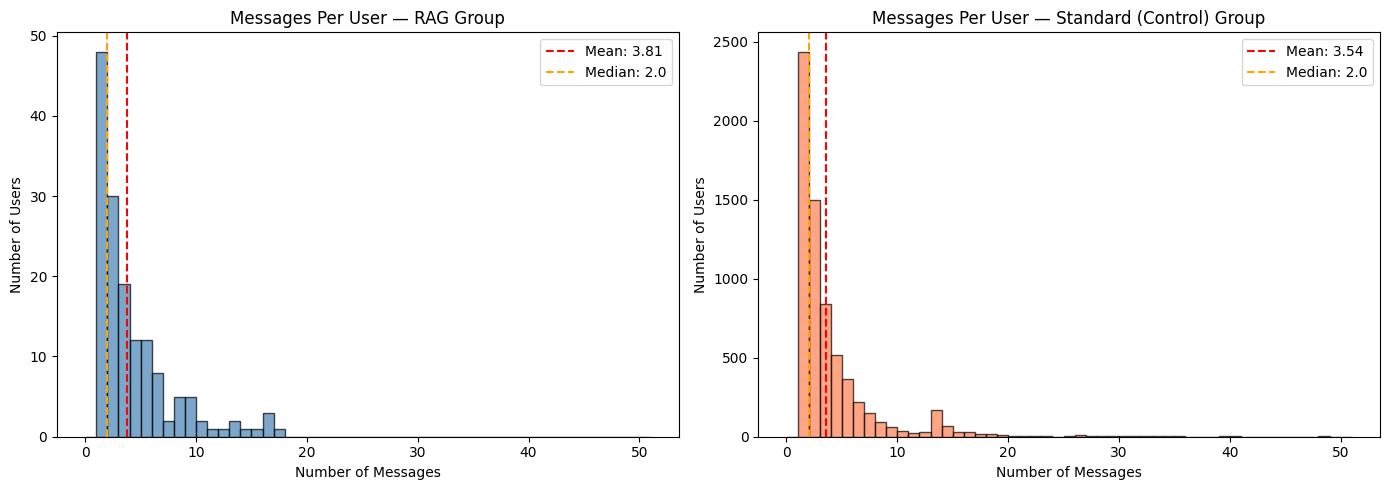

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_bin = max(rag_msgs_per_user.max(), std_msgs_per_user.max())
bins = np.arange(0, min(max_bin + 2, 52), 1)

axes[0].hist(rag_msgs_per_user, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Messages Per User — RAG Group')
axes[0].set_xlabel('Number of Messages')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(rag_msgs_per_user.mean(), color='red', linestyle='--',
                label=f'Mean: {rag_msgs_per_user.mean():.2f}')
axes[0].axvline(rag_msgs_per_user.median(), color='orange', linestyle='--',
                label=f'Median: {rag_msgs_per_user.median():.1f}')
axes[0].legend()

axes[1].hist(std_msgs_per_user, bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Messages Per User — Standard (Control) Group')
axes[1].set_xlabel('Number of Messages')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(std_msgs_per_user.mean(), color='red', linestyle='--',
                label=f'Mean: {std_msgs_per_user.mean():.2f}')
axes[1].axvline(std_msgs_per_user.median(), color='orange', linestyle='--',
                label=f'Median: {std_msgs_per_user.median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. RAG Engagement Rate

Percentage of users who sent at least one message in `RAG_FLOW` (i.e., beyond standard chatbot templates).

In [8]:
total_users_rag = rag['user_id'].nunique()

# Users who have at least one message (from USER) in RAG_FLOW
rag_flow_users = rag[
    (rag['flow_type'] == 'RAG_FLOW') &
    (rag['sender'] == 'USER')
]['user_id'].nunique()

engagement_rate = rag_flow_users / total_users_rag * 100

print(f'Total users in RAG file: {total_users_rag}')
print(f'Users with at least one RAG_FLOW message: {rag_flow_users}')
print(f'Engagement rate: {engagement_rate:.1f}%')

Total users in RAG file: 948
Users with at least one RAG_FLOW message: 244
Engagement rate: 25.7%


## 5. Time Between First and Last Message (Users Enrolled Before 1/15/2026)

For both files, filter for users whose first message was sent before January 15, 2026, then plot the distribution of the time span between their first and last messages.

In [9]:
# Parse timestamps
rag['message_timestamp_dt'] = pd.to_datetime(rag['message_timestamp'], format='mixed')
standard['date_dt'] = pd.to_datetime(standard['date'], format='mixed')

cutoff = pd.Timestamp('2026-01-15')

In [10]:
# --- RAG: first/last message per user ---
rag_user_times = rag.groupby('user_id')['message_timestamp_dt'].agg(['min', 'max'])
rag_user_times.columns = ['first_msg', 'last_msg']

# Filter: enrolled before 1/15/2026
rag_early = rag_user_times[rag_user_times['first_msg'] < cutoff].copy()
rag_early['duration_days'] = (rag_early['last_msg'] - rag_early['first_msg']).dt.total_seconds() / 86400

print(f'RAG users enrolled before 1/15/2026: {len(rag_early)}')
print(f'Duration (days) stats:')
print(rag_early['duration_days'].describe())

RAG users enrolled before 1/15/2026: 112
Duration (days) stats:
count    112.000000
mean      28.631516
std        8.713260
min        0.002801
25%       25.743770
50%       28.572419
75%       31.366189
max       71.142917
Name: duration_days, dtype: float64


In [11]:
# --- Standard: first/last message per user ---
std_user_times = standard.groupby('account_id')['date_dt'].agg(['min', 'max'])
std_user_times.columns = ['first_msg', 'last_msg']

# Filter: enrolled before 1/15/2026
std_early = std_user_times[std_user_times['first_msg'] < cutoff].copy()
std_early['duration_days'] = (std_early['last_msg'] - std_early['first_msg']).dt.total_seconds() / 86400

print(f'Standard users enrolled before 1/15/2026: {len(std_early)}')
print(f'Duration (days) stats:')
print(std_early['duration_days'].describe())

Standard users enrolled before 1/15/2026: 10888
Duration (days) stats:
count    10888.000000
mean        22.654298
std         44.405172
min          0.000000
25%          0.000000
50%          0.000000
75%         25.000000
max        529.000000
Name: duration_days, dtype: float64


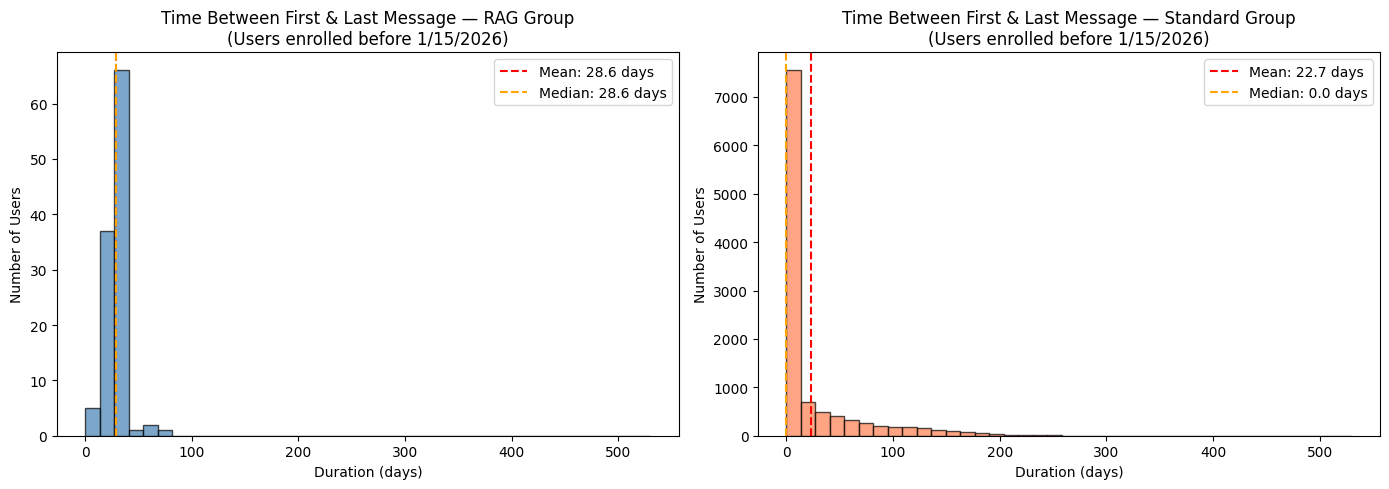

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_days = max(rag_early['duration_days'].max(), std_early['duration_days'].max())
bins = np.linspace(0, max_days + 1, 40)

axes[0].hist(rag_early['duration_days'], bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Time Between First & Last Message — RAG Group\n(Users enrolled before 1/15/2026)')
axes[0].set_xlabel('Duration (days)')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(rag_early['duration_days'].mean(), color='red', linestyle='--',
                label=f'Mean: {rag_early["duration_days"].mean():.1f} days')
axes[0].axvline(rag_early['duration_days'].median(), color='orange', linestyle='--',
                label=f'Median: {rag_early["duration_days"].median():.1f} days')
axes[0].legend()

axes[1].hist(std_early['duration_days'], bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Time Between First & Last Message — Standard Group\n(Users enrolled before 1/15/2026)')
axes[1].set_xlabel('Duration (days)')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(std_early['duration_days'].mean(), color='red', linestyle='--',
                label=f'Mean: {std_early["duration_days"].mean():.1f} days')
axes[1].axvline(std_early['duration_days'].median(), color='orange', linestyle='--',
                label=f'Median: {std_early["duration_days"].median():.1f} days')
axes[1].legend()

plt.tight_layout()
plt.show()